# Plot R7378A JSON Data

In [1]:
# Locate the repository when Jupyter starts in Notebooks/.
from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'Notebooks': PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path: sys.path.insert(0, str(PROJECT_ROOT))

import SRC.KingCRAB.plotting as plotting_helpers
from SRC.KingCRAB.context import configure_module
from SRC.KingCRAB.plotting import plot_two_axis_datasets

from SRC.KingCRAB.digitized import load_digitized_datasets, log_interpolate, log_linear_extrapolation, as_plot_datasets as load_webplotdigitizer_json

from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data_folder = PROJECT_ROOT / "DATA"
characteristics_json = data_folder / "R7378A_Characteristics.json"
spectral_response_json = data_folder / "R7378A_Spectral_Response.json"

for path in [characteristics_json, spectral_response_json]:
    if not path.exists():
        raise FileNotFoundError(f"Could not find {path}")
    print(f"Found: {path}")

Found: /Users/physics/projects/King-CRAB-Analysis/DATA/R7378A_Characteristics.json
Found: /Users/physics/projects/King-CRAB-Analysis/DATA/R7378A_Spectral_Response.json


In [3]:
characteristics = load_webplotdigitizer_json(characteristics_json)
spectral_response = load_webplotdigitizer_json(spectral_response_json)

for label, datasets in [("Characteristics", characteristics), ("Spectral Response", spectral_response)]:
    print(f"\n{label}")
    for dataset in datasets:
        x = dataset["x"]
        y = dataset["y"]
        print(f"  {dataset['name']}: {len(x)} points")
        print(f"    x range: {np.nanmin(x):.4g} to {np.nanmax(x):.4g}")
        print(f"    y range: {np.nanmin(y):.4g} to {np.nanmax(y):.4g}")


Characteristics
  Gain: 10 points
    x range: 500 to 1268
    y range: 8.845e-10 to 8.521e-07
  Anode Dark Current: 11 points
    x range: 500 to 1297
    y range: 143.4 to 1.557e+05

Spectral Response
  Quantum Efficiency: 75 points
    x range: 144.8 to 715
    y range: 0.01153 to 23.64
  Cathode Radiant Sensitivity: 50 points
    x range: 141.6 to 737.3
    y range: 0.01229 to 84.54


In [4]:
configure_module(plotting_helpers, globals())

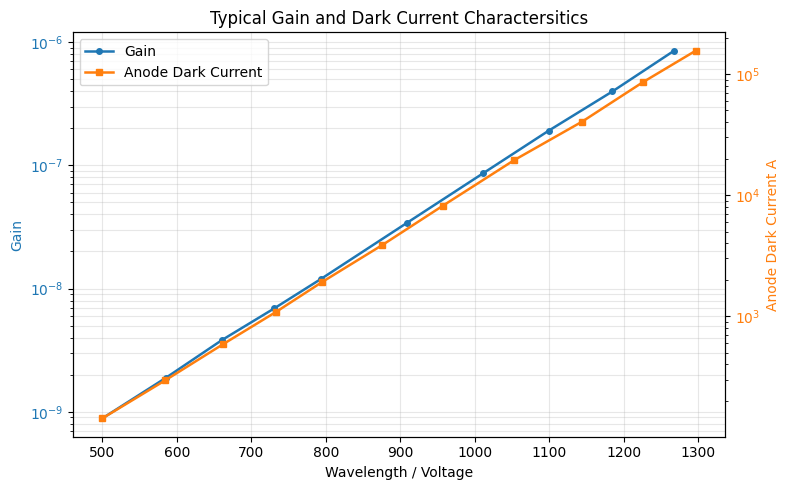

In [5]:
# Plot 1: R7378A characteristics.
# Gain and anode dark current use very different y-scales, so they are shown on separate y-axes.
plot_two_axis_datasets(
    characteristics,
    title="Typical Gain and Dark Current Charactersitics",
    left_label="Gain",
    right_label="Anode Dark Current A",
    yscale="log",
)

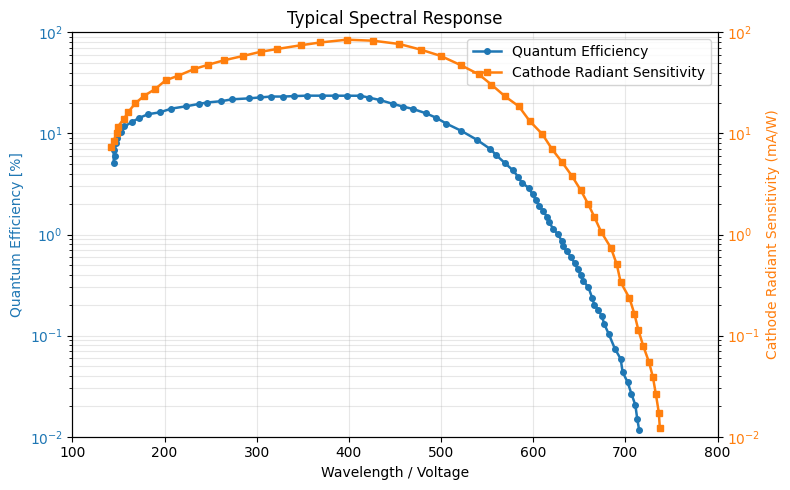

In [6]:
# Plot 2: R7378A spectral response.
# Quantum efficiency and cathode radiant sensitivity are separate quantities, so they are shown on separate y-axes.
plot_two_axis_datasets(
    spectral_response,
    title="Typical Spectral Response",
    left_label="Quantum Efficiency [%]",
    right_label="Cathode Radiant Sensitivity (mA/W)",
    yscale="log",
    xlim=(100, 800),
    ylim=(0.01, 100),
)